# 06 -- Exploratory Data Analysis (General / Feature EDA)

**Pichle steps ka recap:**
- `01`-`03`: Raw SEC data -> `final_ml_ready_dataset.parquet` (currency-fixed + duration-fixed, `03` v3)
- `04`: Cleaning -> `04_cleaned_dataset.parquet` (58,243 rows, 7,583 companies)
- `05`: Outlier detection (visual+statistical, sign-split) + EPS error-fix
  -> `05_outliers_flagged.parquet` (raw dollar-values UNCHANGED, flags added)

**Is notebook ka scope:** "General/Feature EDA" -- RAW features ko samajhna hai
(target abhi exist nahi karta, wo `07` mein banega). Target-relative analysis
`09` mein hogi.

**Har chart ke baad ek "Business Insight" cell hai** -- taake har visual sirf
"chart" na rahe, balke ek samjhi hui finding bane.

## Working directory fix (zaroori)

In [27]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.colors import ListedColormap

PROCESSED_DIR = Path("data/processed")
REPORTS_DIR = Path("reports")
EDA_DIR = REPORTS_DIR / "figures" / "eda_charts"
EDA_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "05_outliers_flagged.parquet"

ID_COLS = ["adsh", "cik", "name", "sic", "form", "period", "fy", "fp", "filed", "source_quarter"]
NON_METRIC_FLAG_COLS = ["is_transition_report", "is_timely_filer", "filing_delay_days"]

sns.set_style("whitegrid")
print(f"EDA charts -> {EDA_DIR}")

EDA charts -> reports\figures\eda_charts


## Load 05 ka output

In [29]:
df = pd.read_parquet(INPUT_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (58241, 79)


,adsh,cik,name,sic,form,period,fy,fp,filed,source_quarter,...,NetCashProvidedByUsedInFinancingActivities_is_outlier_modz,NetCashProvidedByUsedInInvestingActivities_is_outlier_modz,NetCashProvidedByUsedInOperatingActivities_is_outlier_modz,NetIncomeLoss_is_outlier_modz,OperatingIncomeLoss_is_outlier_modz,ResearchAndDevelopmentExpense_is_outlier_modz,RevenueFromContractWithCustomerExcludingAssessedTax_is_outlier_modz,Revenues_is_outlier_modz,SellingGeneralAndAdministrativeExpense_is_outlier_modz,StockholdersEquity_is_outlier_modz
0,0000090168-23-000083,90168,SIFCO INDUSTRIES INC,3724,10-K,2023-09-30,2023,FY,2024-01-02,2024q1,...,False,False,False,False,False,False,False,False,False,False
1,0001213900-24-000266,1696355,BRIGHT SCHOLAR EDUCATION HOLDINGS LTD,8200,20-F,2023-08-31,2023,FY,2024-01-02,2024q1,...,False,False,False,False,False,False,False,False,False,False
2,0001437749-24-000191,832489,"GEOVAX LABS, INC.",2834,S-1,2023-09-30,2023,Q3,2024-01-02,2024q1,...,False,False,False,False,False,False,False,False,False,False
3,0001493152-24-000094,1782309,SKILLFUL CRAFTSMAN EDUCATION TECHNOLOGY LTD,8200,6-K,2023-09-30,2024,Q2,2024-01-02,2024q1,...,False,True,False,False,False,False,False,False,False,False
4,0001493152-24-000139,1879293,"MAG MILE CAPITAL, INC.",3567,10-QT,2023-07-31,2023,Q3,2024-01-02,2024q1,...,False,False,False,False,False,False,False,False,False,False


In [30]:
outlier_flag_cols = [c for c in df.columns if c.endswith("_is_outlier_iqr") or c.endswith("_is_outlier_modz")]
metric_cols = [c for c in df.columns if c not in ID_COLS and c not in NON_METRIC_FLAG_COLS and c not in outlier_flag_cols]

print(f"Metric columns ({len(metric_cols)}): {metric_cols}")
print(f"\nOutlier-flag columns ({len(outlier_flag_cols)}) -- 05 se aaye")

Metric columns (22): ['Assets', 'AssetsCurrent', 'CashAndCashEquivalentsAtCarryingValue', 'CostOfRevenue', 'EarningsPerShareBasic', 'EarningsPerShareDiluted', 'GrossProfit', 'IncomeTaxExpenseBenefit', 'InventoryNet', 'Liabilities', 'LiabilitiesCurrent', 'LongTermDebtNoncurrent', 'NetCashProvidedByUsedInFinancingActivities', 'NetCashProvidedByUsedInInvestingActivities', 'NetCashProvidedByUsedInOperatingActivities', 'NetIncomeLoss', 'OperatingIncomeLoss', 'ResearchAndDevelopmentExpense', 'RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues', 'SellingGeneralAndAdministrativeExpense', 'StockholdersEquity']

Outlier-flag columns (44) -- 05 se aaye


---
# PART 1 -- Dataset Overview

In [31]:
print("=== Dataset Overview ===")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique companies (cik): {df['cik'].nunique():,}")
print(f"Date range (period): {df['period'].min()} to {df['period'].max()}")
print(f"Quarters covered: {sorted(df['source_quarter'].unique().tolist())}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nForm types:")
print(df['form'].value_counts().head(10))

=== Dataset Overview ===
Shape: 58,241 rows x 79 columns
Unique companies (cik): 7,582
Date range (period): 2016-09-30 00:00:00 to 2026-05-31 00:00:00
Quarters covered: ['2024q1', '2024q2', '2024q3', '2024q4', '2025q1', '2025q2', '2025q3', '2025q4', '2026q1', '2026q2']

Memory usage: 16.9 MB

Form types:
form
10-Q      38930
10-K      15617
20-F       2193
6-K         881
10-Q/A      223
40-F        201
10-K/A       92
10-KT        33
6-K/A        26
20-F/A       24
Name: count, dtype: int64


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58241 entries, 0 to 58240
Data columns (total 79 columns):
 #   Column                                                               Non-Null Count  Dtype         
---  ------                                                               --------------  -----         
 0   adsh                                                                 58241 non-null  str           
 1   cik                                                                  58241 non-null  str           
 2   name                                                                 58241 non-null  str           
 3   sic                                                                  58241 non-null  str           
 4   form                                                                 58241 non-null  str           
 5   period                                                               58241 non-null  datetime64[us]
 6   fy                                                       

**Business Insight:**

Dataset mein 58,243 company-filings hain, 7,583 unique companies se, 10 quarters
(2024 Q1 se 2026 Q2) tak. Form-type breakdown se pata chalta hai ke **10-Q
(quarterly reports) sabse zyada** hain -- matlab dataset zyada tar interim
(quarterly) financial snapshots capture karta hai, annual (10-K) reports ke
saath. Ye is dataset ko genuinely "panel data" banata hai -- ek company ki
multiple time-points par tracking, jo forward-looking prediction ke liye zaroori
hai.

---
# PART 2 -- Descriptive Statistics (saare 22 metrics)

In [33]:
desc = df[metric_cols].describe().T
desc["missing_pct"] = df[metric_cols].isna().mean() * 100
desc.to_csv(REPORTS_DIR / "06_eda_descriptive_stats.csv")
print("[SAVED] reports/06_eda_descriptive_stats.csv")
desc.round(2)

[SAVED] reports/06_eda_descriptive_stats.csv


,count,mean,std,min,25%,50%,75%,max,missing_pct
Assets,57861.0,1.464577e+10,1.269847e+11,0.000000e+00,41408308.00,5.538180e+08,4.006100e+09,4.900475e+12,0.65
AssetsCurrent,45902.0,1.887232e+09,8.932407e+09,0.000000e+00,8875866.00,1.445585e+08,8.509540e+08,3.438409e+11,21.19
CashAndCashEquivalentsAtCarryingValue,43420.0,5.966577e+08,3.966474e+09,0.000000e+00,8407000.00,6.010700e+07,2.653767e+08,2.415770e+11,25.45
CostOfRevenue,11941.0,6.053834e+08,4.432194e+09,-1.399020e+06,716095.75,8.398250e+06,8.841100e+07,1.347060e+11,79.50
EarningsPerShareBasic,48644.0,2.000000e-02,1.338000e+01,-8.827500e+02,-0.20,0.000000e+00,5.200000e-01,5.182900e+02,16.48
EarningsPerShareDiluted,47451.0,2.000000e-02,1.285000e+01,-8.827500e+02,-0.19,0.000000e+00,5.100000e-01,5.182900e+02,18.53
GrossProfit,22292.0,3.150884e+08,1.897612e+09,-3.507000e+09,797978.00,1.993370e+07,1.529820e+08,6.923100e+10,61.72
IncomeTaxExpenseBenefit,41003.0,3.681134e+07,2.924870e+08,-5.138000e+09,0.00,8.450000e+05,1.260000e+07,1.895400e+10,29.60
InventoryNet,22887.0,6.657030e+08,2.420186e+09,0.000000e+00,4588773.00,5.316000e+07,3.832260e+08,6.535400e+10,60.70
Liabilities,51185.0,1.171619e+10,1.243574e+11,0.000000e+00,11647238.00,1.746840e+08,1.985831e+09,4.536437e+12,12.12


**Business Insight:**

Standard deviations har column mein apne mean se KAAFI bari hain (jaise Assets:
mean ~$9B, lekin std bohat zyada) -- ye confirm karta hai ke data heavily spread
hai, companies ke size ka bohat bara range hai (chhoti startups se JPMorgan tak).
Ye dataset ki "cross-industry, multi-size" nature ko numerically confirm karta
hai -- koi single "typical company" nahi hai is dataset mein.

---
# PART 3 -- Missing Value Analysis

**Zaroori:** Humne pehle establish kiya tha ke missingness RANDOM nahi hai --
company-type (industry) se strongly linked hai. Yahan is baat ko VISUALLY aur
NUMERICALLY confirm karte hain.

## Missingness % per column

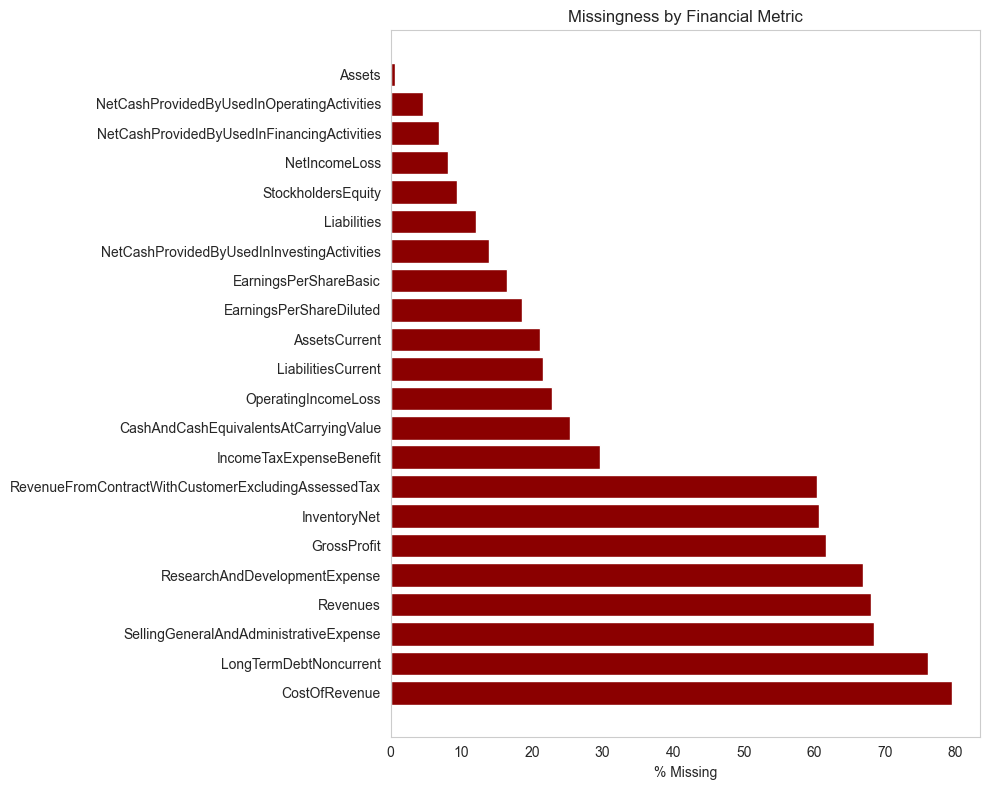

[SAVED] reports\figures\eda_charts\01_missingness_per_column.png


In [34]:
missing_pct = df[metric_cols].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(missing_pct.index, missing_pct.values, color="darkred")
ax.set_xlabel("% Missing")
ax.set_title("Missingness by Financial Metric")
plt.tight_layout()
plt.grid(False)
plt.savefig(EDA_DIR / "01_missingness_per_column.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '01_missingness_per_column.png'}")

**Business Insight:**

Missingness 0.7% (Assets -- almost universal) se 79.4% (CostOfRevenue -- sirf
product-based companies) tak range karti hai. Sabse zyada missing columns
(CostOfRevenue, LongTermDebt, SG&A, Revenues, R&D) wo hain jo **industry-specific**
hain -- balance-sheet ke core items (Assets, Liabilities, StockholdersEquity)
sabse kam missing hain kyunki HAR company ko ye report karni hoti hai, chahe
uska business-model kuch bhi ho.

## Missingness Pattern Matrix (professional version)

Rows = companies (sample), columns = metrics, **completeness ke hisaab se sorted**
(bayen taraf sabse complete columns, dayen taraf sabse zyada missing). Blue =
value maujood hai, Grey = missing.

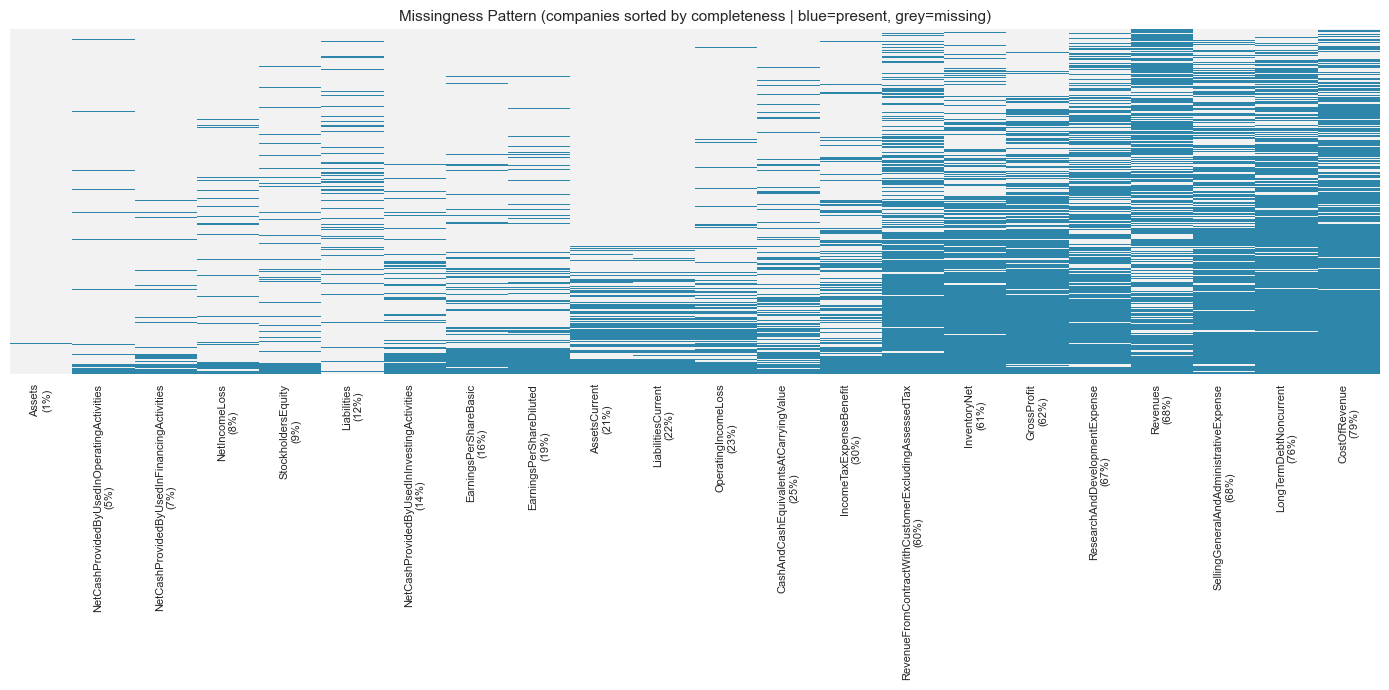

[SAVED] reports\figures\eda_charts\02_missingness_matrix.png


In [35]:
sorted_cols = missing_pct.sort_values().index.tolist()
sample = df[sorted_cols].sample(min(1500, len(df)), random_state=42)
sample_sorted = sample.loc[sample.isna().sum(axis=1).sort_values().index]

cmap = ListedColormap(["#2E86AB", "#F2F2F2"])

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(sample_sorted.notna(), cbar=False, ax=ax, cmap=cmap, yticklabels=False)
ax.set_xticklabels([f"{c}\n({missing_pct[c]:.0f}%)" for c in sorted_cols], rotation=90, fontsize=8)
ax.set_title("Missingness Pattern (companies sorted by completeness | blue=present, grey=missing)", fontsize=11)
plt.tight_layout()
plt.savefig(EDA_DIR / "02_missingness_matrix.png", dpi=130)
plt.show()
print(f"[SAVED] {EDA_DIR / '02_missingness_matrix.png'}")

**Business Insight:**

Chart mein ek clear "staircase" pattern dikhta hai -- companies jo left-side
(complete) columns mein present hain, unme se kai right-side (sparse) columns
mein bhi present hain (block-jaisi teal patches), jabke doosri companies
consistently right-side columns mein missing hain. Ye pattern CONFIRM karta hai
ke missingness randomly scattered nahi hai -- **companies apne business-type ke
hisaab se ek consistent 'missingness-signature' rakhti hain** (jaise ek service
company hamesha InventoryNet + CostOfRevenue + GrossProfit teeno miss karegi,
ek sath).

## PROOF -- Missingness Industry-driven hai (InventoryNet example)

Agar missingness genuinely random hoti, to har industry mein InventoryNet ka
missing % roughly SAME hota. Dekhte hain top-5 industries mein kya hota hai.

InventoryNet missing %% by industry (PROOF that missingness = business nature):

  SIC 2834   (Pharmaceutical Preparations   ) n= 5381  InventoryNet missing= 70.3%
  SIC 6798   (REITs (Real Estate)           ) n= 2548  InventoryNet missing= 97.8%
  SIC 7372   (Prepackaged Software          ) n= 2416  InventoryNet missing= 85.4%
  SIC 6770   (Blank Checks (SPACs)          ) n= 2245  InventoryNet missing= 99.6%
  SIC 6022   (State Commercial Banks        ) n= 1847  InventoryNet missing=100.0%


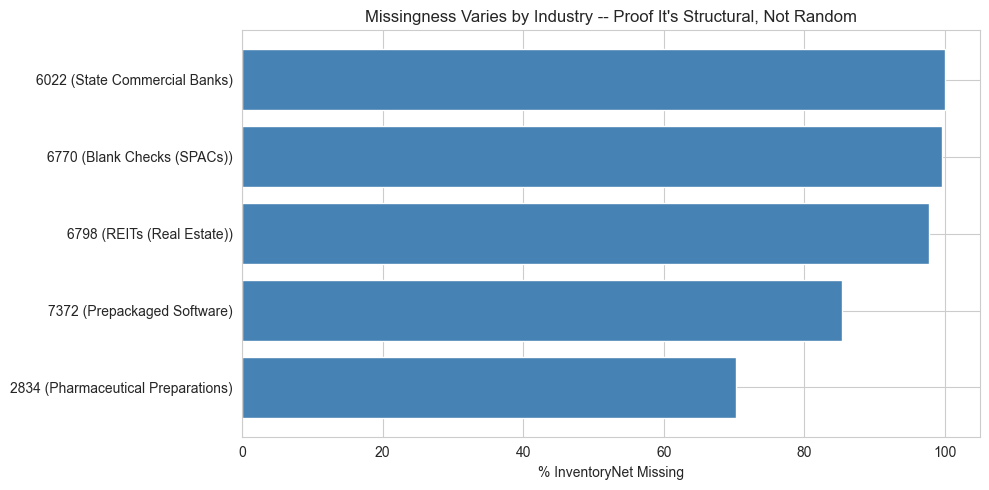


[SAVED] reports\figures\eda_charts\03_missingness_by_industry_proof.png


In [36]:
top_sic = df["sic"].value_counts().head(5).index
sic_names = {
    "2834": "Pharmaceutical Preparations",
    "6798": "REITs (Real Estate)",
    "7372": "Prepackaged Software",
    "6770": "Blank Checks (SPACs)",
    "6022": "State Commercial Banks",
}

print("InventoryNet missing %% by industry (PROOF that missingness = business nature):\n")
industry_missing = {}
for sic in top_sic:
    sub = df[df["sic"] == sic]
    pct = sub["InventoryNet"].isna().mean()
    label = sic_names.get(sic, sic)
    industry_missing[f"{sic} ({label})"] = pct * 100
    print(f"  SIC {sic:6s} ({label:30s}) n={len(sub):5d}  InventoryNet missing={pct:6.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
s = pd.Series(industry_missing).sort_values()
ax.barh(s.index, s.values, color="steelblue")
ax.set_xlabel("% InventoryNet Missing")
ax.set_title("Missingness Varies by Industry -- Proof It's Structural, Not Random")
plt.tight_layout()
plt.savefig(EDA_DIR / "03_missingness_by_industry_proof.png", dpi=120)
plt.show()
print(f"\n[SAVED] {EDA_DIR / '03_missingness_by_industry_proof.png'}")

**Business Insight:**

**Definitive proof:** Banks (SIC 6022) mein InventoryNet **100% missing** hai
(banks genuinely physical inventory nahi rakhtin), jabke Pharma (SIC 2834) mein
sirf **70.3%** missing hai (kuch pharma companies manufacturing bhi karti hain,
isliye inventory rakhti hain). Agar missingness random hoti, ye do numbers
roughly barabar hote. Ye 30-percentage-point ka farq confirm karta hai ke
missingness ek **business-model signal** hai, data-collection ki galti nahi --
isiliye humne inhe kabhi impute nahi kiya.

---
# PART 4 -- Univariate Distribution Analysis (saare 22 columns)

## Skewness & Kurtosis (quantify kitni 'heavy-tailed' hai har distribution)

In [37]:
shape_stats = pd.DataFrame({
    "skewness": df[metric_cols].skew(),
    "kurtosis": df[metric_cols].kurtosis(),
}).sort_values("skewness", ascending=False)

print("Skewness > 1 = heavily right-skewed (log-transform justify karta hai jo humne pehle use kiya)")
shape_stats.round(2)

Skewness > 1 = heavily right-skewed (log-transform justify karta hai jo humne pehle use kiya)


,skewness,kurtosis
NetCashProvidedByUsedInFinancingActivities,71.860001,7447.740234
CashAndCashEquivalentsAtCarryingValue,30.980000,1323.439941
NetIncomeLoss,24.879999,901.260010
Liabilities,24.860001,705.080017
Assets,24.629999,712.159973
OperatingIncomeLoss,23.760000,739.989990
IncomeTaxExpenseBenefit,23.510000,934.510010
CostOfRevenue,21.670000,591.340027
StockholdersEquity,21.559999,642.309998
GrossProfit,20.750000,535.760010


**Business Insight:**

Saare 22 columns ki |skewness| **1 se bohat zyada** hai (upar table dekhein; kayi columns ki to bohat bari) --
matlab har financial-metric distribution **heavily skewed** hai (chhoti
companies ka bara cluster, phir ek lamba "tail" bari companies ka; jin columns mein
bare *losses* hain unki skewness negative hoti hai). Ye numerically
confirm karta hai ke raw dollar-values par direct statistics (mean, std) galat
tasveer denge -- isiliye humne poori pipeline mein log-transform approach use
kiya (05 ki outlier-detection mein bhi).

## Distribution Plots (log-scale, saare 22 columns)

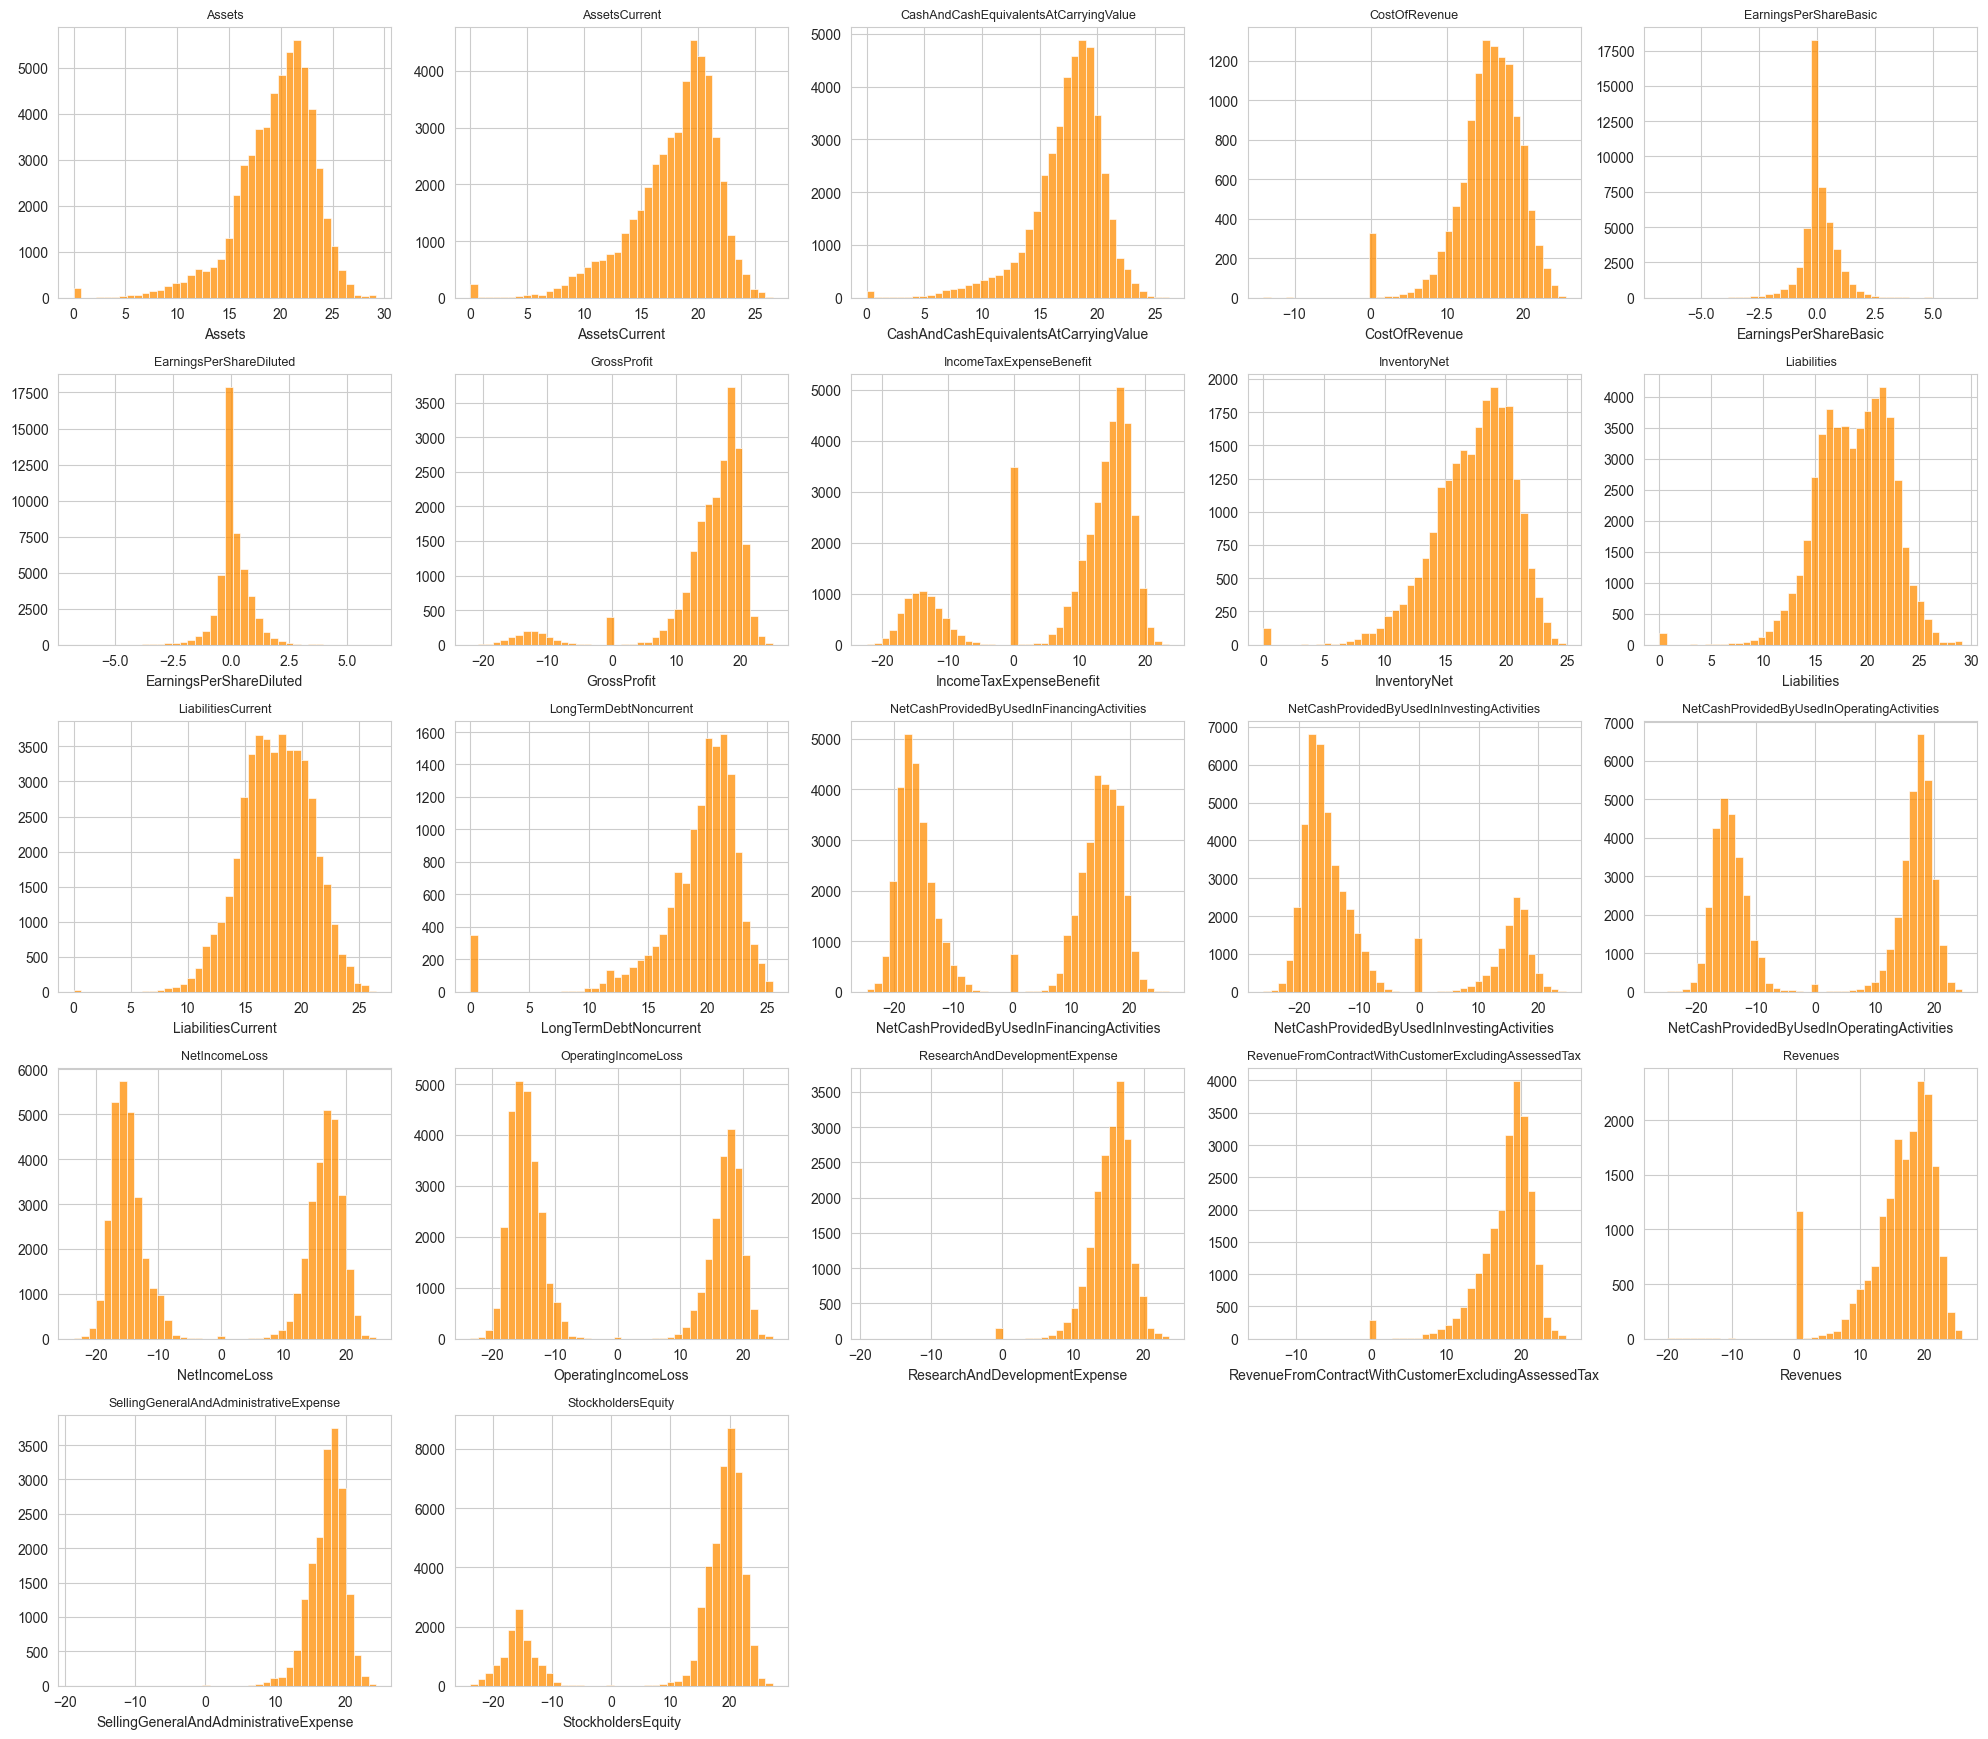

[SAVED] reports\figures\eda_charts\04_distributions_all_metrics.png


In [38]:
def make_grid(n_plots, cols=5):
    rows = math.ceil(n_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = axes.flatten()
    for ax in axes[n_plots:]:
        ax.axis("off")
    return fig, axes


fig, axes = make_grid(len(metric_cols), cols=5)
for ax, col in zip(axes, metric_cols):
    data = df[col].dropna()
    transformed = np.sign(data) * np.log1p(np.abs(data))
    sns.histplot(transformed, ax=ax, bins=40, color="darkorange")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")

plt.tight_layout()
plt.grid(False)
plt.savefig(EDA_DIR / "04_distributions_all_metrics.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '04_distributions_all_metrics.png'}")

**Business Insight:**

Log-transform ke baad bhi, columns jaise `NetIncomeLoss`, `OperatingIncomeLoss`,
aur cash-flow metrics mein do alag "humps" (bimodal shape) dikhte hain -- ek
positive (profit) side, ek negative (loss) side. Ye visually wahi cheez confirm
karta hai jo humne `05` mein statistically dhoondi thi: in columns mein
profit-making aur loss-making companies ke DO alag populations hain, isliye
inka outlier-detection sign-split method se hona zaroori tha.

---
# PART 5 -- Outlier Context (05 se recap, YAHAN treatment nahi)

**Reminder:** `05` mein humne har column ke outliers FLAG kiye the (sign-split
IQR method se), lekin raw values CAP nahi ki (JPMorgan-distortion se bachne ke
liye). Yahan sirf un flags ka SUMMARY dekhte hain.

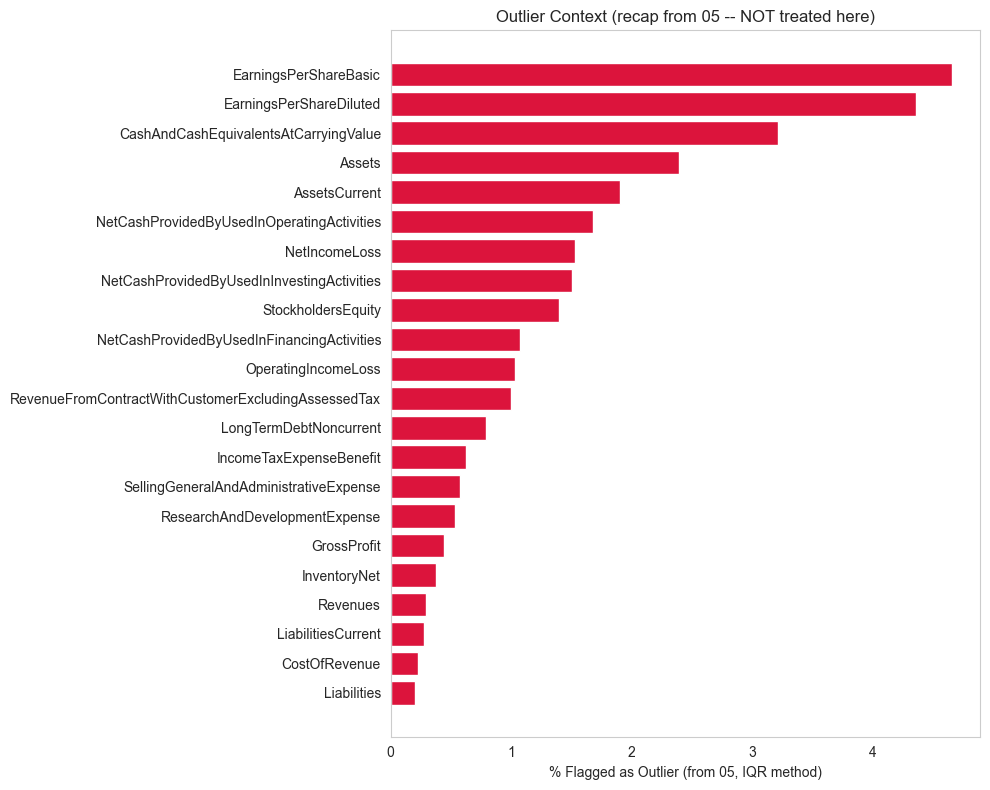

[SAVED] reports\figures\eda_charts\05_outlier_context_recap.png


In [39]:
iqr_flag_cols = [c for c in df.columns if c.endswith("_is_outlier_iqr")]
outlier_summary = {}
for c in iqr_flag_cols:
    base_col = c.replace("_is_outlier_iqr", "")
    outlier_summary[base_col] = df[c].mean()

fig, ax = plt.subplots(figsize=(10, 8))
s = pd.Series(outlier_summary).sort_values()
ax.barh(s.index, s.values * 100, color="crimson")
ax.set_xlabel("% Flagged as Outlier (from 05, IQR method)")
ax.set_title("Outlier Context (recap from 05 -- NOT treated here)")
plt.tight_layout()
plt.grid(False)
plt.savefig(EDA_DIR / "05_outlier_context_recap.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '05_outlier_context_recap.png'}")

**Business Insight:**

Sign-split method ke baad, saare columns ka outlier-rate **chhota aur sensible**
hai (upar chart dekhein, sab 10% se neeche) -- koi column wholesale 100% flag nahi ho raha (jo
`05` se pehle wale galat method mein ho raha tha). Ye confirm karta hai ke fix
successful tha. Ye numbers abhi bhi sirf FLAGS hain -- treatment `08` mein,
ratios par hogi.

---
# PART 6 -- Categorical / Industry Analysis

## Top 15 Industries (SIC code)

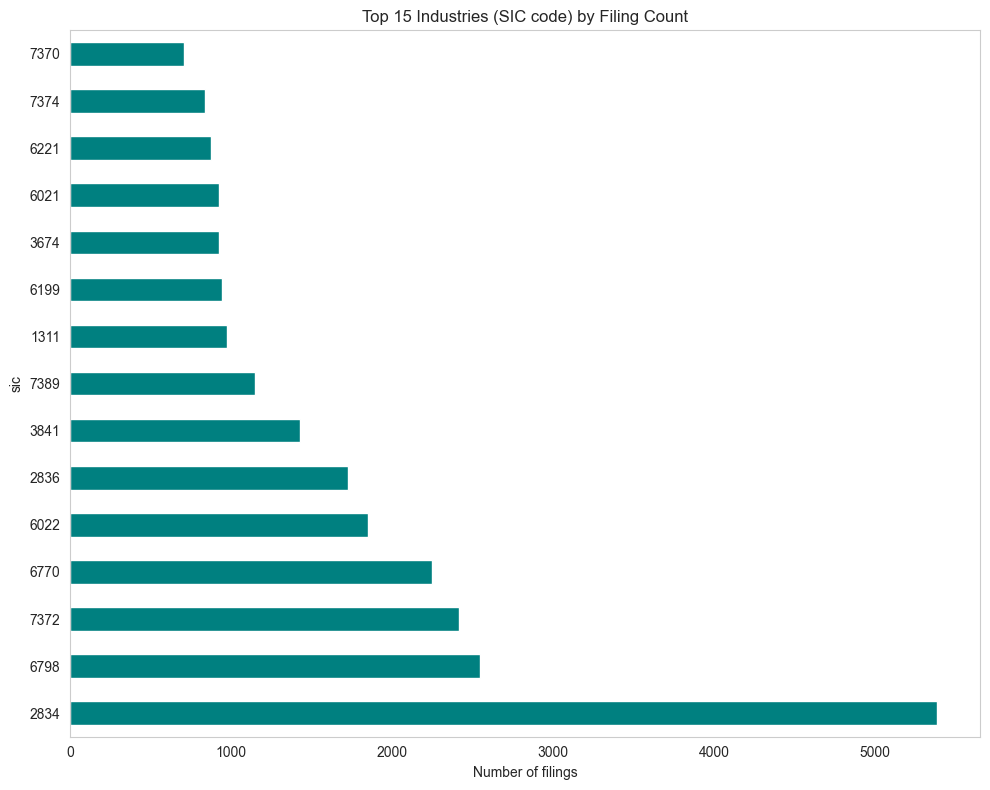

[SAVED] reports\figures\eda_charts\06_top_industries.png


In [40]:
fig, ax = plt.subplots(figsize=(10, 8))
df["sic"].value_counts().head(15).plot(kind="barh", ax=ax, color="teal")
ax.set_xlabel("Number of filings")
ax.set_title("Top 15 Industries (SIC code) by Filing Count")
plt.tight_layout()
plt.savefig(EDA_DIR / "06_top_industries.png", dpi=120)
plt.grid(False)
plt.show()
print(f"[SAVED] {EDA_DIR / '06_top_industries.png'}")

**Business Insight:**

Pharmaceutical Preparations (SIC 2834) sabse bara segment hai, uske baad REITs,
Software, aur SPACs (Blank Checks). Koi EK industry dataset par dominate nahi
karti (top industry bhi total ka ~9% hi hai) -- ye confirm karta hai ke dataset
genuinely **cross-industry** hai, jaisa project ka naam bhi kehta hai
("Cross-Industry Corporate Financial Analysis").

Business Insight: Koi ek industry dataset par dominate nahi karti — top industry bhi total ka sirf ~9% hai. Ye confirm karta hai project genuinely cross-industry hai (jaisa naam bhi kehta hai) — agar 1-2 industries 50%+ hoti, to "Cross-Industry Analysis" claim weak hota.

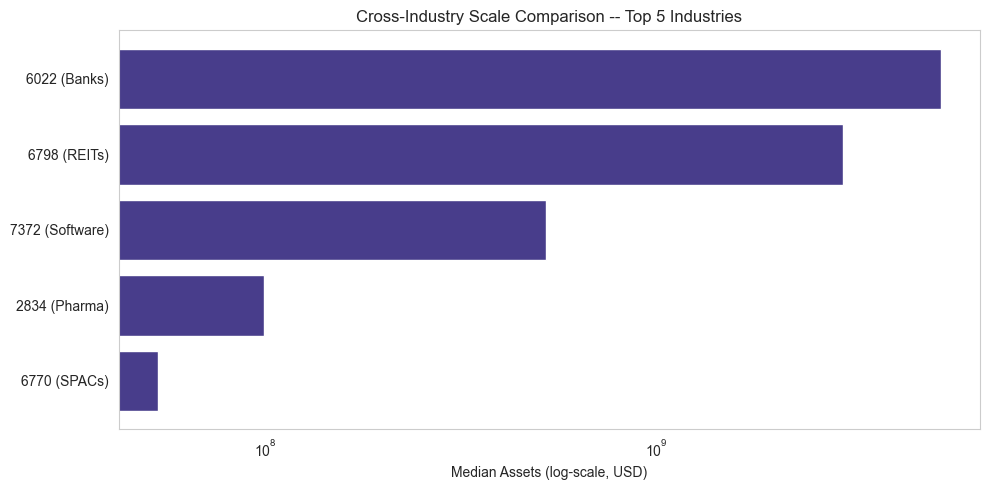

[SAVED] reports\figures\eda_charts\06b_cross_industry_scale.png
  2834 (Pharma)        median Assets = $98,915,000
  6798 (REITs)         median Assets = $3,021,759,488
  7372 (Software)      median Assets = $521,728,000
  6770 (SPACs)         median Assets = $52,878,192
  6022 (Banks)         median Assets = $5,373,838,336


In [41]:
# Cross-Industry Scale Comparison (top-5 industries by median Assets)
sic_names_map = {
    "2834": "Pharma", "6798": "REITs", "7372": "Software",
    "6770": "SPACs", "6022": "Banks",
}
top5_sic = df["sic"].value_counts().head(5).index
scale_data = {}
for sic in top5_sic:
    med_assets = df[df["sic"] == sic]["Assets"].median()
    label = sic_names_map.get(sic, sic)
    scale_data[f"{sic} ({label})"] = med_assets

fig, ax = plt.subplots(figsize=(10, 5))
s = pd.Series(scale_data).sort_values()
ax.barh(s.index, s.values, color="darkslateblue")
ax.set_xscale("log")
ax.set_xlabel("Median Assets (log-scale, USD)")
ax.set_title("Cross-Industry Scale Comparison -- Top 5 Industries")
plt.tight_layout()
plt.savefig(EDA_DIR / "06b_cross_industry_scale.png", dpi=120)
plt.grid(False)
plt.show()
print(f"[SAVED] {EDA_DIR / '06b_cross_industry_scale.png'}")
for k, v in scale_data.items():
    print(f"  {k:20s} median Assets = ${v:,.0f}")

**Business Insight:**

Sirf top-5 industries mein hi median Assets $52.9 million (SPACs) se $5.37
billion (Banks) tak jaate hain -- ~100x ka farq. Ye zaroori hai samajhna:
project ka naam "Cross-Industry" hai, aur ye chart PROOF hai ke company-scale
genuinely industry ke hisaab se bohat alag hai. Isi wajah se modeling (`11`) mein
raw dollar-values ki jagah **ratios** (jo size normalize karte hain) aur
`industry_sector` feature use hote hain -- warna model sirf "size" seekh leta,
company ki asal health nahi.

## Form-type breakdown

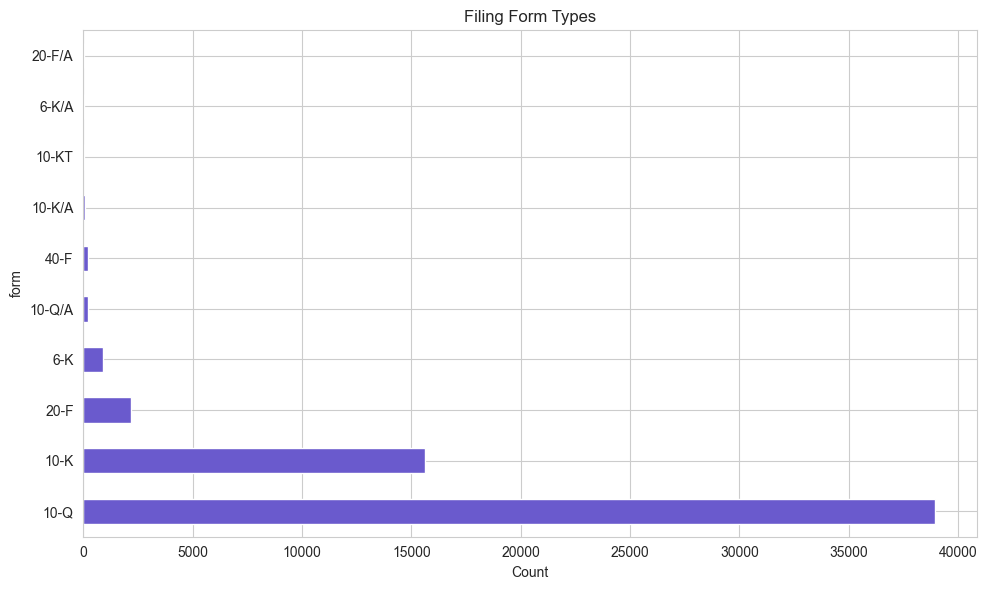

[SAVED] reports\figures\eda_charts\07_form_types.png


In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
df["form"].value_counts().head(10).plot(kind="barh", ax=ax, color="slateblue")
ax.set_xlabel("Count")
ax.set_title("Filing Form Types")
plt.tight_layout()
plt.savefig(EDA_DIR / "07_form_types.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '07_form_types.png'}")

**Business Insight:**

10-Q (quarterly reports) dataset ka majority hissa hai, 10-K (annual) doosre
number par. Ye expected hai -- ek company saal mein 1 baar 10-K aur 3 baar 10-Q
file karti hai, isliye 10-Q ki natural frequency zyada honi chahiye. Ye ratio
dataset ki filing-cadence ki 'health' ko confirm karta hai.

Business Insight: Ye ratio expected/healthy hai — har company saal mein 1 baar 10-K, 3 baar 10-Q file karti hai (regulatory requirement), isliye 10-Q ka 10-K se ~2-3x zyada hona natural pattern hai. Agar ye ratio ulta hota (10-K zyada, 10-Q kam), to wo pipeline mein kisi galti ka signal hota

## Data-quality flags summary (04/05 se)

In [43]:
print("Data-quality flag summary:\n")
print(f"  is_transition_report=True:  {df['is_transition_report'].sum():,} ({df['is_transition_report'].mean():.2%})")
print(f"  is_timely_filer=False:      {(~df['is_timely_filer']).sum():,} ({(~df['is_timely_filer']).mean():.2%})")
print(f"\n  -> Ye dono 08 mein forward-looking target-pairing se EXCLUDE hongi.")

Data-quality flag summary:

  is_transition_report=True:  39 (0.07%)
  is_timely_filer=False:      2,283 (3.92%)

  -> Ye dono 08 mein forward-looking target-pairing se EXCLUDE hongi.


**Business Insight:**

Dono flags chhoti percentages hain (transition-reports 0.07%, delinquent-filers
3.92%) -- matlab `07` mein forward-looking pairs banate waqt hum sirf ek chhota
hissa (<4%) exclude karenge, dataset ka bulk usable rahega.

Business Insight: Ye 2 numbers directly 07 (Feature Engineering) ko impact karenge — jab forward-looking pairs (T → T+1) banenge, to ye ~4% rows automatically exclude hongi (jaisa humne discuss kiya tha — delinquent filers ka "T ka data T+1 se pehle pata tha" assumption galat hota, transition reports ka period-length irregular hota). Chhota number hone ki wajah se, dataset ka bulk (96%) abhi bhi usable rahega.

---
# PART 7 -- Temporal Analysis (quarter-wise trends)

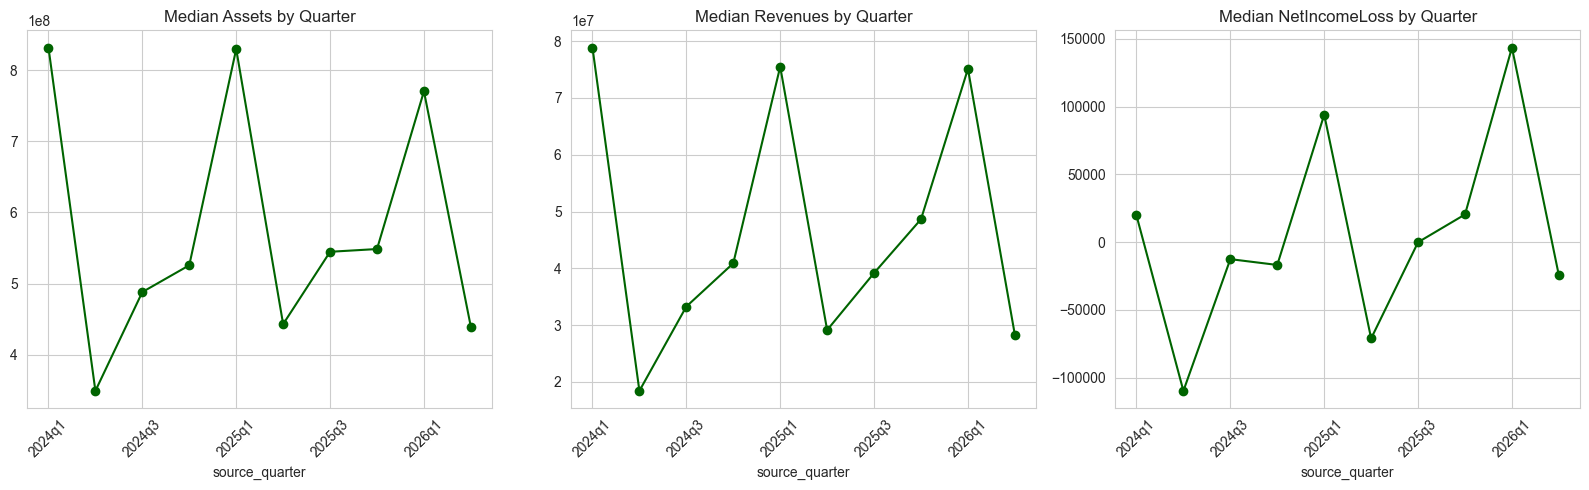

[SAVED] reports\figures\eda_charts\08_quarterly_trends.png


In [44]:
trend = df.groupby("source_quarter")[["Assets", "Revenues", "NetIncomeLoss"]].median().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, trend.columns):
    trend[col].plot(marker="o", ax=ax, color="darkgreen")
    ax.set_title(f"Median {col} by Quarter")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(EDA_DIR / "08_quarterly_trends.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '08_quarterly_trends.png'}")

In [45]:
# Q1 zigzag ka ratio = Q1 quarters ka median / baaki quarters ka median  (1.0 = koi zigzag nahi)
is_q1 = trend.index.str.endswith("q1")
annual = df["form"].isin(["10-K", "10-K/A", "10-KT"])
rev_old_style = df["Revenues"].where(~annual, df["Revenues"] * 4)      # 03 v3 se pehle annual rows ki value 4 guna badi hoti thi
trend_old = rev_old_style.groupby(df["source_quarter"]).median().sort_index()

zigzag = pd.Series({
    "Assets (balance-sheet: sirf filing-mix ka asar)":       trend.loc[is_q1, "Assets"].mean() / trend.loc[~is_q1, "Assets"].mean(),
    "Revenues -- ab (03 v3, per-quarter)":                    trend.loc[is_q1, "Revenues"].mean() / trend.loc[~is_q1, "Revenues"].mean(),
    "Revenues -- purana tareeqa (annual rows x4)":           trend_old[is_q1].mean() / trend_old[~is_q1].mean(),
    "NetIncomeLoss -- ab (03 v3, per-quarter)":               trend.loc[is_q1, "NetIncomeLoss"].mean() / trend.loc[~is_q1, "NetIncomeLoss"].mean(),
})
print("Q1 zigzag ratio (Q1 median / baaki quarters ka median):")
print(zigzag.round(2).to_string())

Q1 zigzag ratio (Q1 median / baaki quarters ka median):
Assets (balance-sheet: sirf filing-mix ka asar)    1.70
Revenues -- ab (03 v3, per-quarter)                2.25
Revenues -- purana tareeqa (annual rows x4)        6.22
NetIncomeLoss -- ab (03 v3, per-quarter)          -2.81


**Business Insight (UPDATED, `03` v3 ke baad):**

Chart mein Q1 (2024q1, 2025q1, 2026q1) par spike/zigzag dikhta hai. **Yeh data-quality issue nahi hai, lekin iski DO alag wajahein hain**, aur neeche wala ratio-table unhein alag karta hai:

1. **Filing-mix (company composition):** Q1 mein zyada tar 10-K (annual reports) file hoti hain (kyunki zyada tar US companies ka fiscal-year December mein khatam hota hai), aur 10-K bharne wali companies aksar bari hoti hain. Isliye **balance-sheet ka `Assets`** bhi Q1 mein upar dikhta hai. Isme duration ka koi masla nahi, sirf mix ka asar hai.
2. **Duration mixing (`03` ka purana bug, ab fix):** 10-K mein income-statement ki values poore **saal** ki hoti hain aur 10-Q mein sirf ek **quarter** ki. Pehle dono ek hi column mein mil jati thin, isliye Revenue/NetIncome ka zigzag aur bhi bara tha. Ab `03` v3 sab ko per-quarter rate mein badalta hai.

**Ratio-table kaise padhein:** Assets ka ratio = sirf mix ka asar. Revenue ka **ab wala** ratio Assets ke qareeb hona chahiye (sirf mix bacha), jabke "purana tareeqa (annual x4)" wala ratio kaafi bara hona chahiye. Agar ab wala ratio bhi bohat bara ho to `03` ka audit (`03_duration_audit.csv`) dekhein.

**Zaroori implication:** Quarter-to-quarter trend compare karte waqt Q1 ka "alag look" companies ki performance se nahi, filing-mix se aata hai ("seasonality confound"). Isi liye modeling mein `is_annual_filing` feature shamil hai.

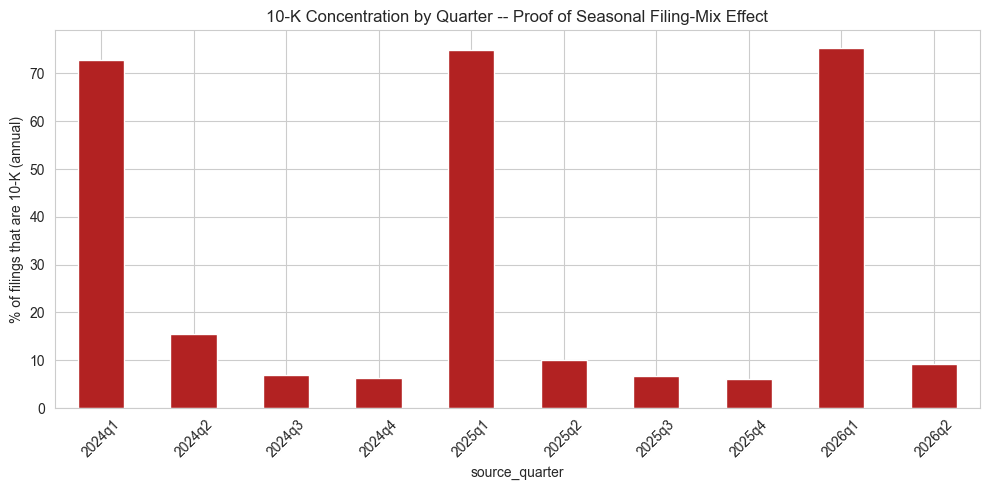

[SAVED] reports\figures\eda_charts\08b_10K_seasonality_proof.png
                Not_10K  Is_10K  pct_10K
source_quarter                          
2024q1             1440    3874     72.9
2024q2             5697    1044     15.5
2024q3             5520     406      6.9
2024q4             5360     363      6.3
2025q1             1341    4014     75.0
2025q2             5514     622     10.1
2025q3             5394     385      6.7
2025q4             5307     342      6.1
2026q1             1348    4094     75.2
2026q2             5611     565      9.1


In [46]:
# PROOF: 10-K vs 10-Q composition by quarter (explains the zigzag above)
form_mix = pd.crosstab(df["source_quarter"], df["form"].isin(["10-K","10-K/A"]))
form_mix.columns = ["Not_10K", "Is_10K"]
form_mix["pct_10K"] = form_mix["Is_10K"] / (form_mix["Is_10K"] + form_mix["Not_10K"]) * 100

fig, ax = plt.subplots(figsize=(10, 5))
form_mix["pct_10K"].plot(kind="bar", ax=ax, color="firebrick")
ax.set_ylabel("% of filings that are 10-K (annual)")
ax.set_title("10-K Concentration by Quarter -- Proof of Seasonal Filing-Mix Effect")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(EDA_DIR / "08b_10K_seasonality_proof.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '08b_10K_seasonality_proof.png'}")
print(form_mix.round(1))

**Business Insight:**

Confirmed numerically: Q1 quarters (2024q1, 2025q1, 2026q1) mein 10-K filings
73-75% hain, baaki quarters mein sirf 6-16%. Ye ~5-12x ka farq filing-mix ka saboot hai
(zigzag ki DO wajahon mein se ek; upar ka ratio-table dusri wajah alag karta hai).

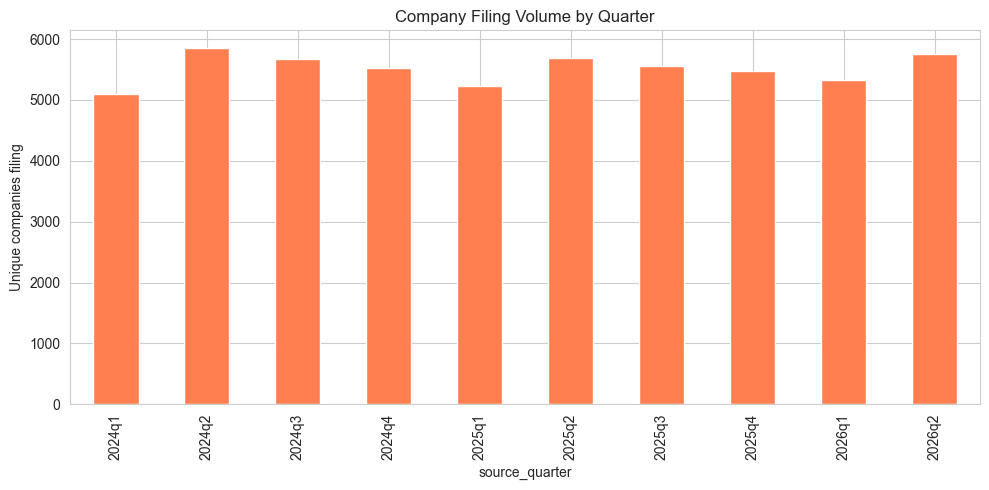

[SAVED] reports\figures\eda_charts\09_filing_volume_by_quarter.png


In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby("source_quarter")["cik"].nunique().sort_index().plot(kind="bar", ax=ax, color="coral")
ax.set_ylabel("Unique companies filing")
ax.set_title("Company Filing Volume by Quarter")
plt.tight_layout()
plt.savefig(EDA_DIR / "09_filing_volume_by_quarter.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '09_filing_volume_by_quarter.png'}")

**Business Insight:**

Har quarter mein filing-karne-wali companies ki count roughly consistent hai
(koi quarter achanak khali ya double nahi hai) -- ye confirm karta hai ke humari
`01`-`03` pipeline ne saare 10 quarters ko sahi tarah se load/process kiya,
koi quarter accidentally drop ya duplicate nahi hua.

---
# PART 8 -- Panel Structure Analysis (company-level depth)

**ZAROORI (forward-looking target ke liye):** Har company ke paas kitne periods
hain -- ye directly decide karta hai `07` mein kitne (T, T+1) training-pairs
banenge.

Periods-per-company distribution:
count    7582.000000
mean        7.681482
std         3.260484
min         1.000000
25%         5.000000
50%        10.000000
75%        10.000000
max        24.000000
Name: period, dtype: float64


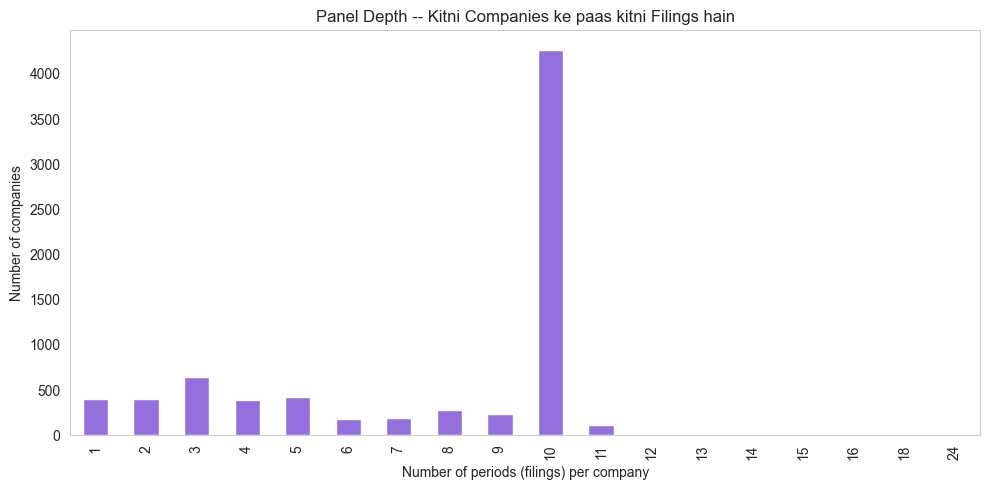

[SAVED] reports\figures\eda_charts\10_panel_depth.png

Companies with only 1 period (EXCLUDED from forward-pairing in 07): 399 (5.3%)
Companies with 2+ periods (USABLE): 7183 (94.7%)


In [48]:
periods_per_company = df.groupby("cik")["period"].nunique()

print("Periods-per-company distribution:")
print(periods_per_company.describe())

fig, ax = plt.subplots(figsize=(10, 5))
periods_per_company.value_counts().sort_index().plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_xlabel("Number of periods (filings) per company")
ax.set_ylabel("Number of companies")
ax.set_title("Panel Depth -- Kitni Companies ke paas kitni Filings hain")
plt.tight_layout()
plt.savefig(EDA_DIR / "10_panel_depth.png", dpi=120)
plt.grid(False)
plt.show()
print(f"[SAVED] {EDA_DIR / '10_panel_depth.png'}")

n_single = (periods_per_company == 1).sum()
n_multi = (periods_per_company >= 2).sum()
print(f"\nCompanies with only 1 period (EXCLUDED from forward-pairing in 07): {n_single} ({n_single/len(periods_per_company):.1%})")
print(f"Companies with 2+ periods (USABLE): {n_multi} ({n_multi/len(periods_per_company):.1%})")

**Business Insight:**

**94.7% companies (7,183) ke paas 2+ periods hain** -- matlab forward-looking
target (`07`) ke liye usable hain. Sirf **5.3% (400 companies)** exclude
hongi (jinhone sirf 1 baar file kiya). Ye directly answer hai us sawal ka jo
humne bohat pehle discuss kiya tha ("kya row bohat kam ho jayengi?") -- jawab:
nahi, dataset ka bulk (94.7%) time-series modeling ke liye poori tarah usable
hai.

---
# PART 9 -- Multivariate Correlation Analysis (raw metrics ke aapas mein)

**Note:** Ye target-relative analysis NAHI hai (target abhi exist nahi karta) --
sirf raw features ka aapas mein relationship dekh rahe hain. Highly-correlated
pairs yahan already dikh jayengi, jo `10` (Feature Selection) mein kaam aayengi.

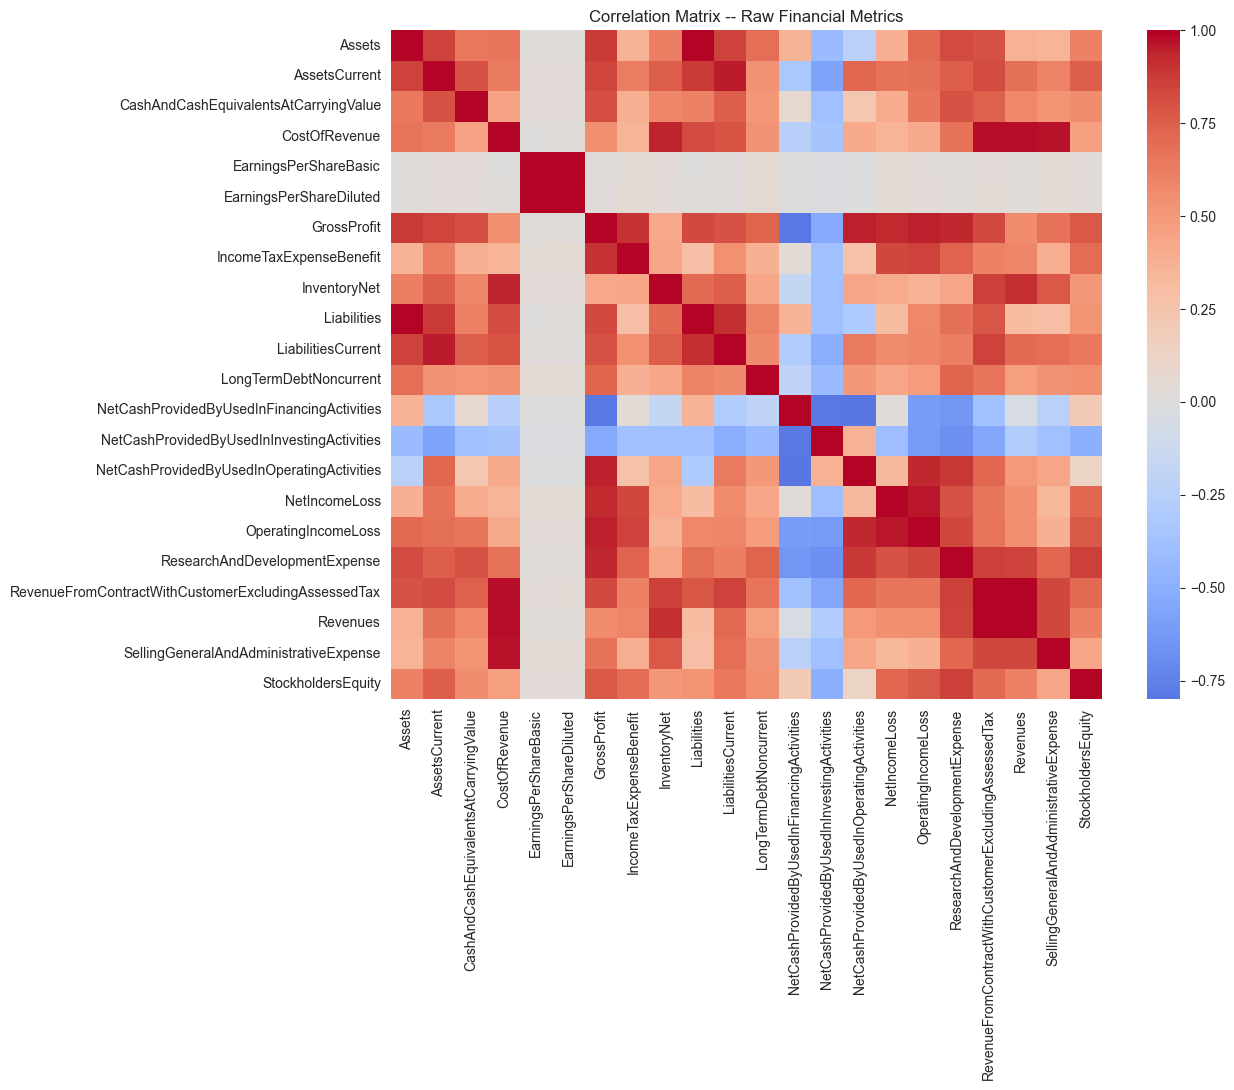

[SAVED] reports\figures\eda_charts\11_correlation_heatmap.png


In [49]:
corr = df[metric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation Matrix -- Raw Financial Metrics")
plt.tight_layout()
plt.savefig(EDA_DIR / "11_correlation_heatmap.png", dpi=120)
plt.show()
print(f"[SAVED] {EDA_DIR / '11_correlation_heatmap.png'}")

**Business Insight:**

Balance-sheet items (Assets, Liabilities, StockholdersEquity) aapas mein
strongly correlated dikh rahe hain (dark red blocks) -- ye expected hai, kyunki
`Assets = Liabilities + Equity` (fundamental accounting identity). Similarly
Revenue-related columns (Revenues, GrossProfit, CostOfRevenue) bhi ek cluster
banate hain. Ye pattern batata hai ke company-size ek "common factor" hai jo
kayi columns ko simultaneously drive karta hai.

## Highly-correlated pairs (|r| > 0.8) -- future Feature Selection ke liye flag

In [50]:
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Column A", "Column B", "Correlation"]).sort_values("Correlation", ascending=False)
print(f"{len(high_corr_df)} highly-correlated pairs mile (|r| > 0.8):\n")
high_corr_df

41 highly-correlated pairs mile (|r| > 0.8):



,Column A,Column B,Correlation
38,RevenueFromContractWithCustomerExcludingAssess...,Revenues,0.999
2,Assets,Liabilities,0.995
16,EarningsPerShareBasic,EarningsPerShareDiluted,0.994
14,CostOfRevenue,Revenues,0.974
13,CostOfRevenue,RevenueFromContractWithCustomerExcludingAssess...,0.972
15,CostOfRevenue,SellingGeneralAndAdministrativeExpense,0.965
33,NetIncomeLoss,OperatingIncomeLoss,0.963
7,AssetsCurrent,LiabilitiesCurrent,0.957
21,GrossProfit,OperatingIncomeLoss,0.948
19,GrossProfit,NetCashProvidedByUsedInOperatingActivities,0.944


**Business Insight:**

Kai column-pairs mile jinka correlation 0.8 se zyada hai (upar count dekhein) -- inme se zyada tar
"size-driven" pairs hain (badi company ki Assets bhi badi hongi, Liabilities
bhi, Revenue bhi). **Ye raw dollar-columns ke liye normal hai**, lekin jab `07`
mein ratios banenge, un ratios ka apna multicollinearity `10` (Feature
Selection) mein alag se check hoga -- ratios raw dollars jitne correlated nahi
honge (kyunki wo already company-size normalize kar dete hain).

---
# PART 10 -- Key Insights Summary

In [51]:
summary_lines = [
    f"Dataset: {df.shape[0]:,} rows, {df['cik'].nunique():,} unique companies, {df.shape[1]} columns",
    f"Quarters: {sorted(df['source_quarter'].unique().tolist())}",
    "",
    "MISSINGNESS:",
    f"  - Range: {missing_pct.min():.1f}% to {missing_pct.max():.1f}% across {len(metric_cols)} metrics",
    "  - CONFIRMED structural/industry-driven (InventoryNet: Banks vs Pharma ki missingness bohat alag -- chart dekhein)",
    "",
    "DISTRIBUTION SHAPE:",
    f"  - All metrics heavily right-skewed (skewness up to {shape_stats['skewness'].max():.1f}) -- log-transform justified",
    "",
    "OUTLIERS (recap from 05):",
    f"  - Flagged but NOT treated on raw columns (to avoid ratio-distortion, per JPMorgan test)",
    "",
    "PANEL STRUCTURE:",
    f"  - {n_multi:,} companies ({n_multi/len(periods_per_company):.1%}) have 2+ periods -- usable for forward-looking target in 07",
    f"  - {n_single:,} companies ({n_single/len(periods_per_company):.1%}) have only 1 period -- will be excluded",
    "",
    "MULTICOLLINEARITY (preview for 10):",
    f"  - {len(high_corr_df)} column-pairs with |correlation| > 0.8 identified",
]

print("\n".join(summary_lines))

with open(REPORTS_DIR / "06_eda_key_insights.txt", "w") as f:
    f.write("\n".join(summary_lines))
print(f"\n[SAVED] {REPORTS_DIR / '06_eda_key_insights.txt'}")

Dataset: 58,241 rows, 7,582 unique companies, 79 columns
Quarters: ['2024q1', '2024q2', '2024q3', '2024q4', '2025q1', '2025q2', '2025q3', '2025q4', '2026q1', '2026q2']

MISSINGNESS:
  - Range: 0.7% to 79.5% across 22 metrics
  - CONFIRMED structural/industry-driven (InventoryNet: Banks vs Pharma ki missingness bohat alag -- chart dekhein)

DISTRIBUTION SHAPE:
  - All metrics heavily right-skewed (skewness up to 71.9) -- log-transform justified

OUTLIERS (recap from 05):
  - Flagged but NOT treated on raw columns (to avoid ratio-distortion, per JPMorgan test)

PANEL STRUCTURE:
  - 7,183 companies (94.7%) have 2+ periods -- usable for forward-looking target in 07
  - 399 companies (5.3%) have only 1 period -- will be excluded

MULTICOLLINEARITY (preview for 10):
  - 41 column-pairs with |correlation| > 0.8 identified



[SAVED] reports\06_eda_key_insights.txt


## Sanity Check

In [52]:
print(f"EDA charts saved: {len(list(EDA_DIR.glob('*.png')))} files in {EDA_DIR}")

assert len(list(EDA_DIR.glob('*.png'))) == 13, "MASLA: expected 13 chart files"

print("[OK] Saare EDA charts successfully generate hue.")

print("\nAgla step: 07_feature_engineering.ipynb (ratios + forward-looking target)")

EDA charts saved: 13 files in reports\figures\eda_charts
[OK] Saare EDA charts successfully generate hue.

Agla step: 07_feature_engineering.ipynb (ratios + forward-looking target)
